##Árboles de decisión para especies de flores

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
data = pd.read_csv('/content/drive/MyDrive/Machine Learning - Python/Datasets - Machine Learning/iris/iris.csv')

In [4]:
data.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


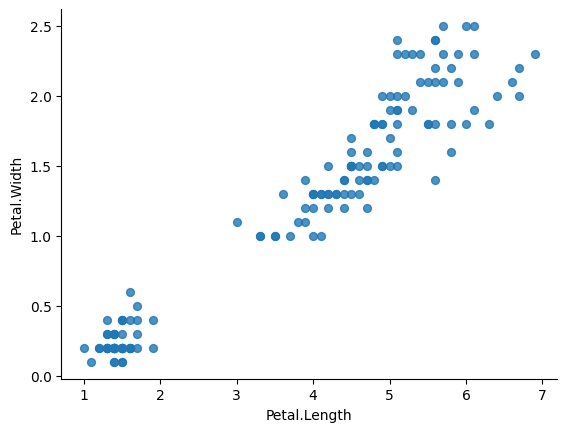

In [5]:
# @title Petal.Length vs Petal.Width

from matplotlib import pyplot as plt
data.plot(kind='scatter', x='Petal.Length', y='Petal.Width', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

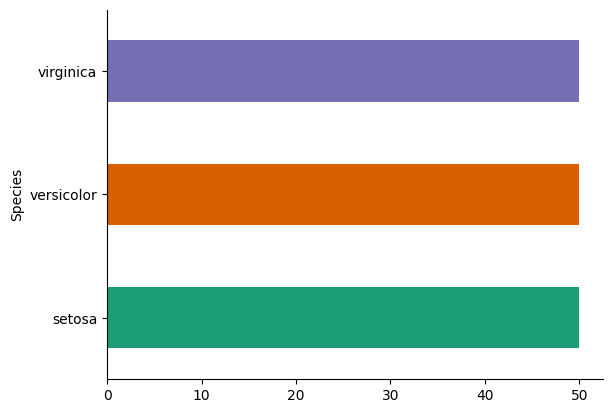

In [6]:
# @title Species

from matplotlib import pyplot as plt
import seaborn as sns
data.groupby('Species').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [7]:
data.shape

(150, 5)

(array([50.,  0.,  0.,  0.,  0., 50.,  0.,  0.,  0., 50.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

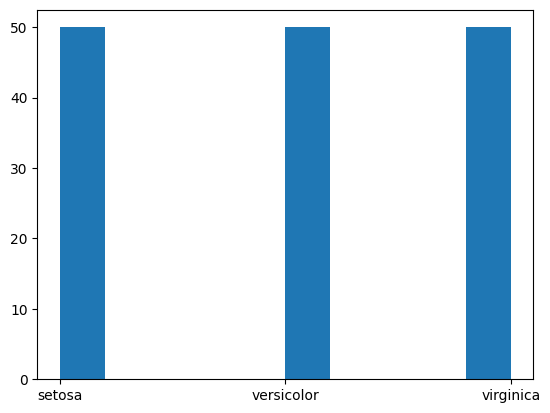

In [8]:
plt.hist(data.Species)

In [9]:
data.Species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [10]:
colnames = data.columns.values
colnames

array(['Sepal.Length', 'Sepal.Width', 'Petal.Length', 'Petal.Width',
       'Species'], dtype=object)

In [11]:
colnames = colnames.tolist()
colnames

['Sepal.Length', 'Sepal.Width', 'Petal.Length', 'Petal.Width', 'Species']

In [12]:
predictors = colnames[:4]
predictors

['Sepal.Length', 'Sepal.Width', 'Petal.Length', 'Petal.Width']

In [13]:
target = colnames[4]
target

'Species'

In [14]:
data['is_train'] = np.random.uniform(0, 1, len(data)) <= 0.75
data.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,is_train
0,5.1,3.5,1.4,0.2,setosa,False
1,4.9,3.0,1.4,0.2,setosa,True
2,4.7,3.2,1.3,0.2,setosa,True
3,4.6,3.1,1.5,0.2,setosa,True
4,5.0,3.6,1.4,0.2,setosa,False


In [15]:
data['is_train']


,is_train
0,False
1,True
2,True
3,True
4,False
...,...
145,False
146,True
147,True
148,True


In [16]:
data.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,is_train
0,5.1,3.5,1.4,0.2,setosa,False
1,4.9,3.0,1.4,0.2,setosa,True
2,4.7,3.2,1.3,0.2,setosa,True
3,4.6,3.1,1.5,0.2,setosa,True
4,5.0,3.6,1.4,0.2,setosa,False


In [17]:
train, test = data[data['is_train'] == True], data[data['is_train']  == False]

In [18]:
from sklearn.tree import DecisionTreeClassifier


In [19]:
tree = DecisionTreeClassifier(criterion = 'entropy', min_samples_split = 20, random_state = 99)

In [20]:
tree.fit(train[predictors], train[target])

DecisionTreeClassifier(criterion='entropy', min_samples_split=20,
                       random_state=99)

In [21]:
preds = tree.predict(test[predictors])

In [22]:
pd.crosstab(test[target], preds, rownames = ['Actual'], colnames = ['Predictions'])

Predictions,setosa,versicolor,virginica
Actual,,,
setosa,15,0,0
versicolor,0,15,1
virginica,0,2,8


#Visualización del árbol



In [23]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

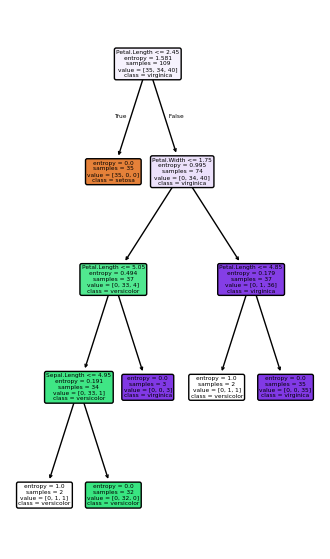

In [24]:
plt.figure(figsize = (4, 7))  # Ajusta el tamaño del gráfico según necesites
plot_tree(tree, feature_names = predictors, class_names = ['setosa', 'versicolor', 'virginica'], filled = True, rounded = True)
plt.show()

CROSS VALIDATION PARA LA PODA


In [25]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score

In [26]:
X = data[predictors]
Y = data[target]

In [27]:
# Definir el modelo de árbol de decisión
tree = DecisionTreeClassifier(random_state=42)

# Definir los hiperparámetros para la validación cruzada
param_grid = {
    'max_depth': np.arange(1, 10)  # Probamos varias profundidades del árbol
}



In [28]:
grid_search = GridSearchCV(estimator=tree, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X, Y)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': array([1, 2, 3, 4, 5, 6, 7, 8, 9])},
             scoring='accuracy')

In [29]:
# Obtener la mejor profundidad del árbol
best_depth = grid_search.best_params_['max_depth']
print(f"La mejor profundidad del árbol es: {best_depth}")

# Obtener el mejor modelo entrenado
best_tree = grid_search.best_estimator_

La mejor profundidad del árbol es: 3


In [30]:
# Evaluar el mejor modelo en el mismo conjunto de datos (o en conjunto de prueba si lo tienes)
accuracy = accuracy_score(Y, best_tree.predict(X))
print(f"Precisión del mejor modelo después de la poda: {accuracy}")

Precisión del mejor modelo después de la poda: 0.9733333333333334


In [31]:
# Mostrar la precisión media obtenida para cada profundidad de árbol
mean_scores = grid_search.cv_results_['mean_test_score']
depths = param_grid['max_depth']

for depth, score in zip(depths, mean_scores):
    print(f"Profundidad: {depth}, Precisión media en CV: {score}")

Profundidad: 1, Precisión media en CV: 0.6666666666666666
Profundidad: 2, Precisión media en CV: 0.9333333333333332
Profundidad: 3, Precisión media en CV: 0.9733333333333334
Profundidad: 4, Precisión media en CV: 0.9533333333333334
Profundidad: 5, Precisión media en CV: 0.9533333333333334
Profundidad: 6, Precisión media en CV: 0.9533333333333334
Profundidad: 7, Precisión media en CV: 0.9533333333333334
Profundidad: 8, Precisión media en CV: 0.9533333333333334
Profundidad: 9, Precisión media en CV: 0.9533333333333334


##RANDOM FOREST

In [32]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
forest = RandomForestClassifier(n_jobs = 2, oob_score = True, n_estimators = 10)

In [34]:
forest.fit(X,Y)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:615: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


RandomForestClassifier(n_estimators=10, n_jobs=2, oob_score=True)

In [35]:
forest.oob_score_

0.94

In [36]:
forest.oob_decision_function_

array([[1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [0.75      , 0.25      , 0.        ],
       [0.83333333, 0.16666667, 0.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [0.75      , 0.25      , 0.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [1.